In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wildfire
from wildfire.utils.functions import G
from wildfire.utils import plots, gradient
from matplotlib.animation import FuncAnimation
from optimizer import optimizer_object
from IPython.display import HTML

import scipy.optimize as opt

%load_ext autoreload
%autoreload 2

# Random fuel initial condition
def b0(x, y):
    np.random.seed(666)
    br = lambda x, y: np.round(np.random.uniform(size=(x.shape)), decimals=2)
    B = br(x, y)
    x_rows, x_cols = x.shape
    y_rows, y_cols = y.shape
    B[0,:] = np.zeros(x_cols)
    B[-1,:] = np.zeros(x_cols)
    B[:,0] = np.zeros(y_rows)
    B[:,-1] = np.zeros(y_rows)
    return B

In [33]:
import io
import contextlib


param_names = [
    r"$x_1$", r"$y_1$", r"$\theta_1$", r"$t_1$",
    r"$x_2$", r"$y_2$", r"$\theta_2$", r"$t_2$",
]


def make_history_callback(opt_obj):
    history = {
        "iteration": [],
        "z": [],            # normalized controls
        "control_vars": [], # physical controls
        "objective": [],
        "grad_z": [],       # gradient w.r.t. normalized controls
        "grad_physical": [],
        "grad_norm": [],
    }

    def record(z):
        z = np.asarray(z, dtype=float).copy()

        # Suppress the diagnostic prints currently inside objective_function/gradient.
        with contextlib.redirect_stdout(io.StringIO()):
            J = float(opt_obj.objective_function(z))
            grad_z = np.asarray(opt_obj.gradient(z), dtype=float).copy()

        physical_controls = opt_obj.denormalize(z)
        grad_physical = grad_z / opt_obj.norm_range

        history["iteration"].append(len(history["iteration"]))
        history["z"].append(z)
        history["control_vars"].append(physical_controls)
        history["objective"].append(J)
        history["grad_z"].append(grad_z)
        history["grad_physical"].append(grad_physical)
        history["grad_norm"].append(np.linalg.norm(grad_z))

    def callback(xk):
        # xk is the normalized parameter vector after each accepted iteration.
        record(xk)

    callback.record = record
    callback.history = history
    return callback


def plot_optimization_history(history):
    it = np.asarray(history["iteration"])
    J = np.asarray(history["objective"])
    controls = np.asarray(history["control_vars"])
    grad_z = np.asarray(history["grad_z"])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(it, J, "o-")
    ax.set(xlabel="Accepted iteration", ylabel="Objective", title="Objective history")
    ax.grid(True)
    plt.show()

    fig, axes = plt.subplots(4, 2, figsize=(11, 10), sharex=True)
    for j, ax in enumerate(axes.flat):
        ax.plot(it, controls[:, j], "o-")
        ax.set_ylabel(param_names[j])
        ax.grid(True)
    axes[-1, 0].set_xlabel("Accepted iteration")
    axes[-1, 1].set_xlabel("Accepted iteration")
    fig.suptitle("Physical control parameters")
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(4, 2, figsize=(11, 10), sharex=True)
    for j, ax in enumerate(axes.flat):
        ax.plot(it, grad_z[:, j], "o-")
        ax.set_ylabel(rf"$\partial J / \partial z_{j + 1}$")
        ax.grid(True)
    axes[-1, 0].set_xlabel("Accepted iteration")
    axes[-1, 1].set_xlabel("Accepted iteration")
    fig.suptitle("Gradient with respect to normalized controls")
    fig.tight_layout()
    plt.show()

In [4]:
## Physical and Simulation Parameters

# Model parameters #
kap = 1
eps = 3e-1
# upc = 3.
alp = 1e-3
q = 1
x_min, x_max = -100, 100
y_min, y_max = -100, 100
t_min, t_max = 0, 10

# Numerical #
# Space
space_method = 'FD'
Nx = 252
Ny = 252
acc = 2
sparse = False

# Time
time_method = 'Euler'
Nt = 150
last = False

# Initial conditions
u0 = lambda x, y: 6 * G(x+25, y+25, 100)

# test case initial fuel 
fuel_properties = {"forest_beta":0.9, "forest_u":3.5, "shrub_beta":0.45, "shrub_u":3.0, "grass_beta":0.2, "grass_u":2.5}
def b_test_intermediate(x, y):
    x_rows, x_cols = x.shape
    y_rows, y_cols = y.shape
    xmid = (x[-1,0] - x[0,0]) // 2
    ymid = (y[0,-1] - y[0,0]) //2
    forest_beta, shrub_beta, grass_beta = 0.9, 0.45, 0.2
    B = np.where(x <= xmid, forest_beta, grass_beta).astype(float)
    shrub_mask = (x >= xmid) & (y <= ymid)   
    B[shrub_mask] = shrub_beta

    # homogenous dirichlet boundary conditions
    B[0,:] = np.zeros(x_cols)
    B[-1,:] = np.zeros(x_cols)
    B[:,0] = np.zeros(y_rows)
    B[:,-1] = np.zeros(y_rows)
    return B

# initial u_pc (ignition temp) conditions
B_test = b_test_intermediate(*np.meshgrid(np.linspace(x_min, x_max, Nx), np.linspace(y_min, y_max, Ny)))
u_pc = np.ones_like(B_test)
u_pc[B_test==0.9] = 3.5 # forest
u_pc[B_test==0.45] = 3.0 # shrub
u_pc[B_test==0.2] = 2.5 # grass

# asset/weight map, 2 assets on the left-hand side directly in line with fire.
weights = np.ones_like(B_test) * 0.5 # 0.5 weight everywhere in general
asset_weight = 10
x_num, y_num = np.shape(B_test)
asset_size = 12
# first asset
x_asset1, y_asset1 = (2*x_num//4)+35, (2*y_num//4)+30
weights[x_asset1-asset_size:x_asset1+asset_size,  y_asset1-asset_size : y_asset1+asset_size] = asset_weight
u_pc[x_asset1-asset_size:x_asset1+asset_size,  y_asset1-asset_size : y_asset1+asset_size] = 3.0
# 2nd asset
x_asset2, y_asset2 = (2*x_num//4), (2*y_num//4)+30
weights[x_asset2-asset_size:x_asset2+asset_size,  y_asset2-asset_size : y_asset2+asset_size] = asset_weight
u_pc[x_asset2-asset_size:x_asset2+asset_size,  y_asset2-asset_size : y_asset2+asset_size] = 3.0

def b0_test(x, y):
    B = b_test_intermediate(x, y)
    x_num, y_num = np.shape(B)
    asset_size = 12
    x_asset1, y_asset1 = (2*x_num//4)+35, (2*y_num//4)+30
    x_asset2, y_asset2 = (2*x_num//4), (2*y_num//4)+30
    B[x_asset1-asset_size:x_asset1+asset_size,  y_asset1-asset_size : y_asset1+asset_size] = 0.7 # 0.7 fuel at assets.
    B[x_asset2-asset_size:x_asset2+asset_size,  y_asset2-asset_size : y_asset2+asset_size] = 0.7
    return B


# Wind effect
gamma = 7
w1 = lambda x, y, t: gamma * np.cos(np.pi/4 + x * 0)
w2 = lambda x, y, t: gamma * np.sin(np.pi/4 + x * 0)
V = lambda x, y, t: (w1(x, y, t), w2(x, y, t))
### PARAMETERS ###

# Physical parameters for the model
physical_parameters = {    
    'kap': kap, # diffusion coefficient
    'eps': eps, # inverse of activation energy
    'upc': u_pc, # u phase change map.
    'q': q, # reaction heat
    'alp': alp, # natural convection,
    # Domain
    'x_lim': (x_min, x_max), # x-axis domain 
    'y_lim': (y_min, y_max), # y-axis domain
    't_lim': (t_min, t_max) # time domain
}

drop_1 = [0, 0, (3/4)*np.pi, 1]
drop_2 = [20, 20, (3/4)*np.pi, 4]
control_vars = np.asarray([drop_1, drop_2])

# CONTROL PARAMETERS
control_params = {
    'v':5,
    'sigma_x':5.5,
    'sigma_y':5.5,
    'T':3,
    'k': 0.6, # original value was 0.5
    'delta': 0.2,
    'control_vars':control_vars
}

In [5]:
bounds = [
    (x_min, x_max),       # x1
    (y_min, y_max),       # y1
    (0, np.inf),  # theta1
    (0, 4),       # t1
    (x_min, x_max),       # x2
    (y_min, y_max),       # y2
    (0, np.inf),  # theta2
    (0, 4),       # t2
]

normalization_ranges = np.array([[x_min, x_max], [y_min, y_max], [0, 2*np.pi], [0, 10], [x_min, x_max], [y_min, y_max], [0, 2*np.pi], [0, 10]])

In [92]:
### Initialize optimizer object
opt_obj = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b0_test, V, weights)# Try forward eval
x0 = np.asarray([0, 0, (3/4)*np.pi, 3, 20, 20, (3/4)*np.pi, 6])






grad : [  2.40032715 -25.57345987 129.90502039 387.75782718   3.92705936
   5.18974563 -11.01403033   3.67418232]
vars : [1.00000000e-02 1.00000000e-02 2.36619449e+00 3.01000000e+00
 2.00100000e+01 2.00100000e+01 2.36619449e+00 6.01000000e+00]
1729.1264621768378
vars : [-1.00000000e-02 -1.00000000e-02  2.34619449e+00  2.99000000e+00
  1.99900000e+01  1.99900000e+01  2.34619449e+00  5.99000000e+00]
1726.9883860638008
 Adjoint value is [  2.40032715 -25.57345987 129.90502039 387.75782718   3.92705936
   5.18974563 -11.01403033   3.67418232]
 Finite difference value is 106.90380565184796


In [52]:
# Try Backward Eval and Gradient Computation
grad = opt_obj.gradient(control_vars)
print(grad)

grad : [  3.34986539 -26.77477687 114.27426998 394.69312487   3.31713168
   4.04863601  -7.48341982  19.4160912 ]
[  3.34986539 -26.77477687 114.27426998 394.69312487   3.31713168
   4.04863601  -7.48341982  19.4160912 ]


In [6]:
### Try with Scipy Optimize
normalization_ranges = np.array([[x_min, x_max], [y_min, y_max], [0, 2*np.pi], [0, 10], [x_min, x_max], [y_min, y_max], [0, 2*np.pi], [0, 10]])

opt_obj = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b0_test, V, weights, normalization_ranges)

x0 = np.asarray([-25, -25, (1/4)*np.pi, 0, 0, 0, (3/4)*np.pi, 3]) # initial guess
z0 = (x0 - normalization_ranges[:,0])/ (normalization_ranges[:,1] - normalization_ranges[:,0]) 
J_ref = opt_obj.objective_function(z0)
func_scaled = lambda z: opt_obj.objective_function(z) / J_ref
jac_scaled = lambda z: opt_obj.gradient(z) / J_ref
bounds_z = opt.Bounds(lb=np.zeros(8), ub=np.ones(8))

#callback = make_history_callback(opt_obj)
#callback.record(z0)

res = opt.minimize(func_scaled, x0=z0, args=(), method="trust-constr", jac=jac_scaled, bounds=bounds_z,
                     options={"verbose": 2,"maxiter": 100,"initial_tr_radius": 0.05,"gtol": 1e-5})
# history = callback.history
# plot_optimization_history(history)

| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |   1   |   0   | +1.0000e+00 | 5.00e-02 | 1.89e+02 | 0.00e+00 |
|   2   |   2   |   1   | +8.5888e-01 | 5.00e-02 | 2.40e+03 | 6.29e-05 |
|   3   |   3   |   2   | +8.2650e-01 | 5.00e-02 | 2.15e+03 | 7.01e-03 |
|   4   |   4   |   3   | +8.4833e-01 | 5.00e-02 | 4.97e+03 | 1.64e-02 |
|   5   |   5   |   5   | +8.7518e-01 | 5.00e-02 | 9.80e+02 | 1.94e-02 |
|   6   |   6   |   8   | +8.4585e-01 | 5.00e-02 | 6.01e+02 | 2.11e-02 |
|   7   |   7   |  13   | +8.5437e-01 | 5.00e-02 | 4.17e+02 | 2.79e-02 |
|   8   |   8   |  16   | +8.5954e-01 | 5.00e-02 | 5.67e+02 | 3.28e-02 |
|   9   |   9   |  20   | +8.6114e-01 | 5.00e-02 | 2.49e+02 | 3.64e-02 |
|  10   |  10   |  24   | +8.7242e-01 | 5.00e-02 | 1.68e+02 | 4.06e-02 |
|  11   |  11   |  30   | +8.7330e-01 | 5.00e-02 | 1.01e+02 | 4.34e-02 |
|  12   |  12   |  35   | +8.7428e-01 | 5.00e-02 | 

/opt/anaconda3/envs/wildfire/lib/python3.10/site-packages/scipy/optimize/_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


|  62   |  87   |  170  | +4.7034e-01 | 1.25e-02 | 1.26e+02 | 0.00e+00 |
|  63   |  88   |  173  | +4.3067e-01 | 1.25e-02 | 3.71e+03 | 0.00e+00 |
|  64   |  89   |  175  | +4.1414e-01 | 1.25e-02 | 7.80e+02 | 0.00e+00 |
|  65   |  90   |  178  | +4.0043e-01 | 1.25e-02 | 4.22e+02 | 0.00e+00 |
|  66   |  91   |  181  | +3.4107e-01 | 1.25e-02 | 9.73e+02 | 0.00e+00 |
|  67   |  92   |  184  | +1.4922e-01 | 1.25e-02 | 8.56e+04 | 0.00e+00 |
|  68   |  94   |  186  | +1.4922e-01 | 6.25e-03 | 8.56e+04 | 0.00e+00 |
|  69   |  96   |  187  | +1.4922e-01 | 3.13e-03 | 8.56e+04 | 0.00e+00 |
|  70   |  98   |  188  | +1.4922e-01 | 1.56e-03 | 8.56e+04 | 0.00e+00 |
|  71   |  99   |  189  | +1.2451e-01 | 1.56e-03 | 5.25e+03 | 0.00e+00 |
|  72   |  100  |  191  | +1.2216e-01 | 1.56e-03 | 1.63e+02 | 0.00e+00 |
|  73   |  101  |  193  | +1.1929e-01 | 1.56e-03 | 1.13e+02 | 0.00e+00 |
|  74   |  102  |  195  | +1.1784e-01 | 1.56e-03 | 1.52e+01 | 0.00e+00 |
|  75   |  103  |  198  | +1.1743e-01 | 1.56e-03 | 

In [7]:
print(res)

           message: The maximum number of function evaluations is exceeded.
           success: False
            status: 0
               fun: 0.11714045191672794
                 x: [ 3.905e-01  4.045e-01  9.770e-02  1.467e-05  4.719e-01
                      4.347e-01  3.807e-01  2.146e-01]
               nit: 100
              nfev: 141
              njev: 141
              nhev: 0
          cg_niter: 236
      cg_stop_cond: 2
              grad: [ 4.189e+02 -3.937e+02 -5.270e+01  3.146e+02  6.267e+00
                     -6.050e+00  5.877e-01  1.822e+01]
   lagrangian_grad: [ 4.087e+01 -3.964e+01 -4.929e-01  9.039e-09  6.904e-01
                     -6.424e-01  5.554e-02  7.478e-01]
            constr: [array([ 3.905e-01,  4.045e-01,  9.770e-02,  1.467e-05,
                            4.719e-01,  4.347e-01,  3.807e-01,  2.146e-01])]
               jac: [<Compressed Sparse Row sparse matrix of dtype 'float64'
                    	with 8 stored elements and shape (8, 8)>]
       con

Objective function value is 595.9478479707554
t:  0.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


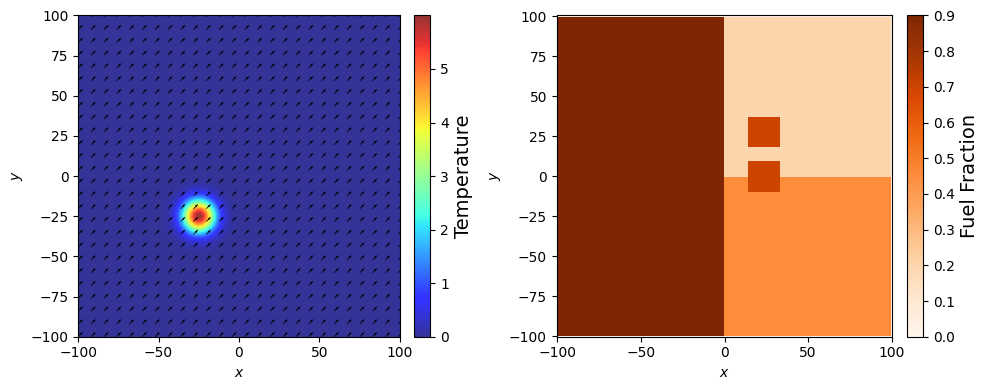

t:  2.466666666666667
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


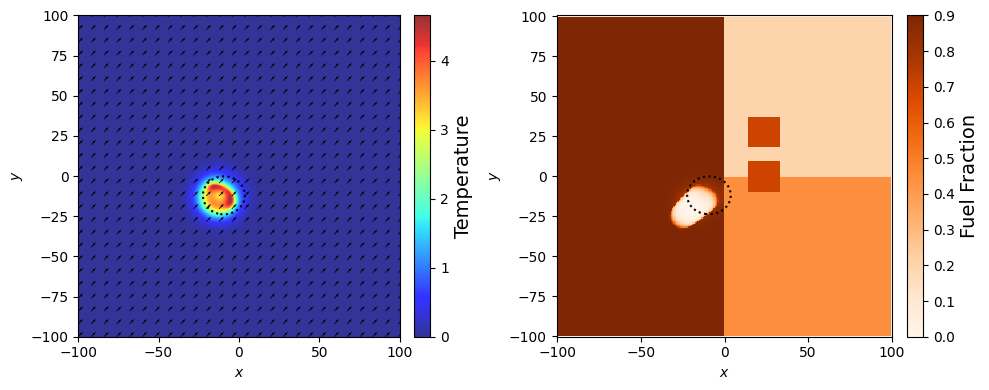

t:  5.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


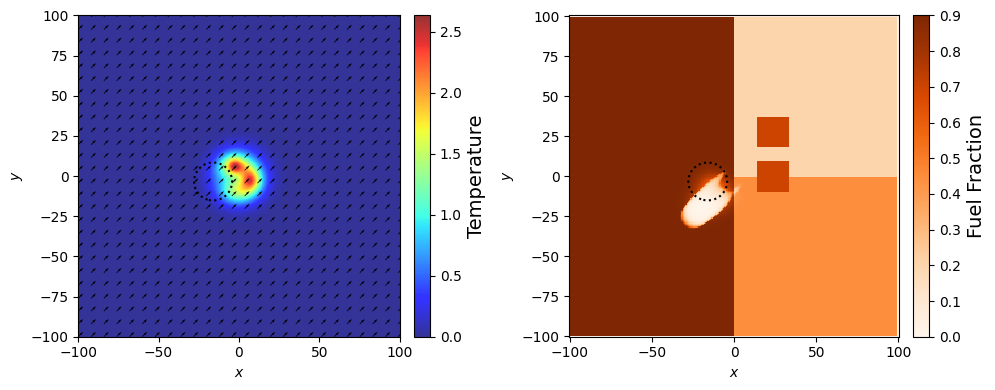

t:  7.466666666666667
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


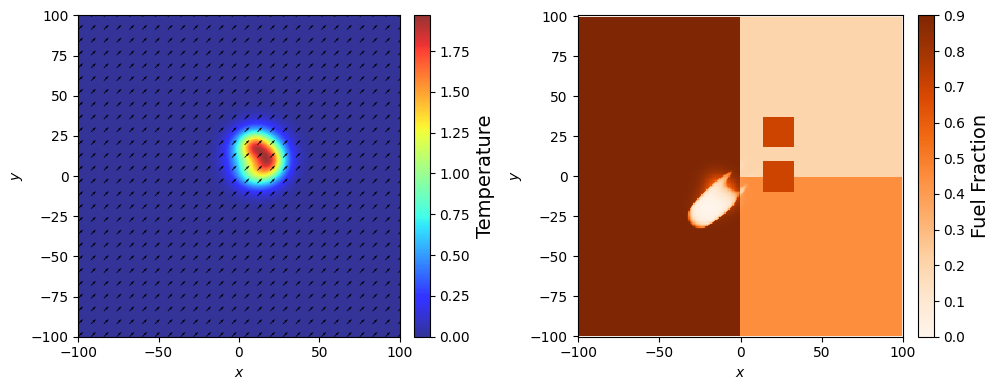

t:  10.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


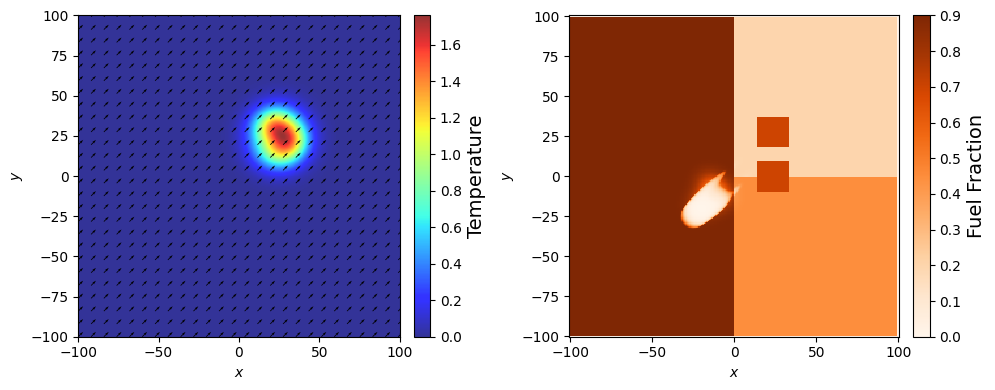

In [8]:
#x0 = np.asarray([-25, -25, (1/4)*np.pi, 0, 0, 0, (3/4)*np.pi, 3])
#x0 = np.asarray([-1.71892889e+01, -2.39543285e+01,  1.05329321e+00,  0.00000000e+00,-9.93221252e-01, -7.85744799e-04,  3.13988268e+00,  2.35460332e+00])
z0 = res.x
opt_obj1 = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b0_test, V, weights, normalization_ranges)
x0 = opt_obj1.denormalize(z0)
control_params['control_vars'] = x0
opt_obj = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b0_test, V, weights, normalization_ranges)


t, X, Y, U, B = opt_obj.forward_eval(x0 , full_out=True)
print(f"Objective function value is {opt_obj.objective_function(z0)}")
Ns = np.linspace(0, Nt, 5, dtype=int)
for n in Ns:
    plots.UBs(n, t, X, Y, U, B, V, control_params, forward=True)

In [9]:
print(x0)

[-2.18969226e+01 -1.91017462e+01  6.13863104e-01  1.46738846e-04
 -5.62333099e+00 -1.30615703e+01  2.39173766e+00  2.14551118e+00]


t:  0.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


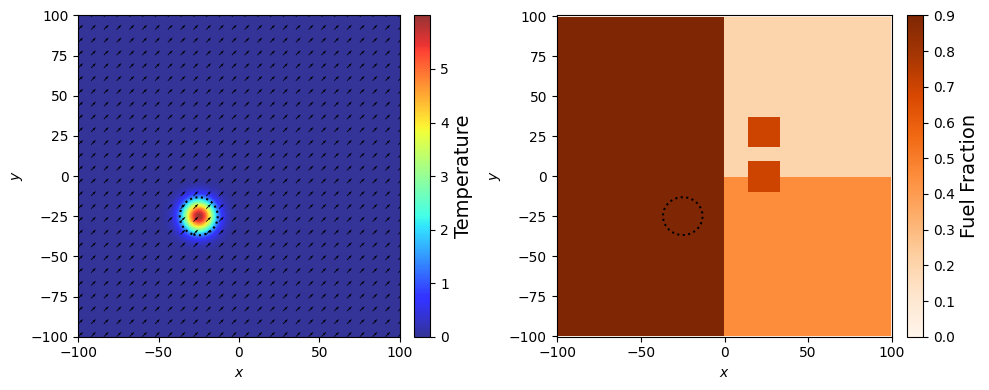

t:  2.466666666666667
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


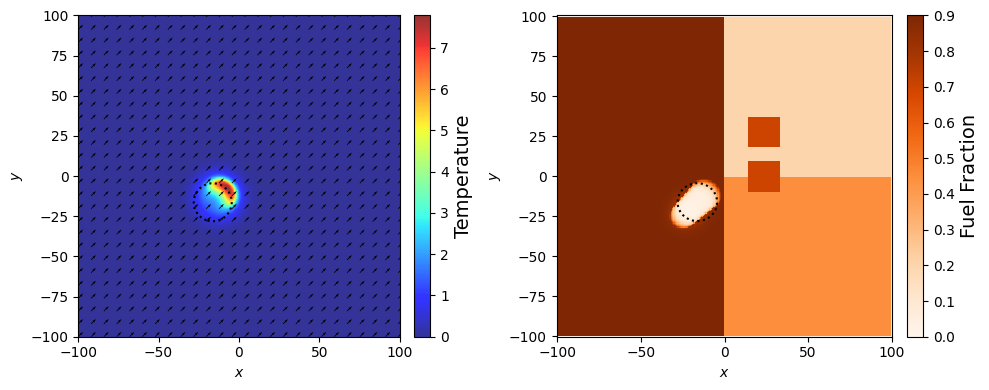

t:  5.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


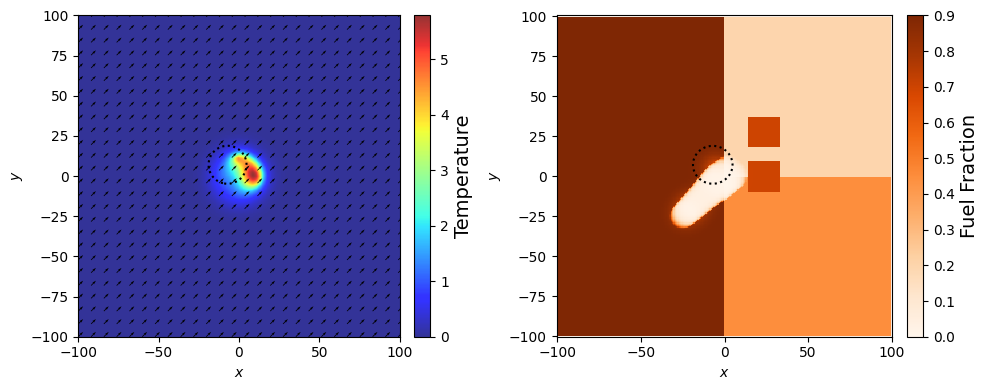

t:  7.466666666666667
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


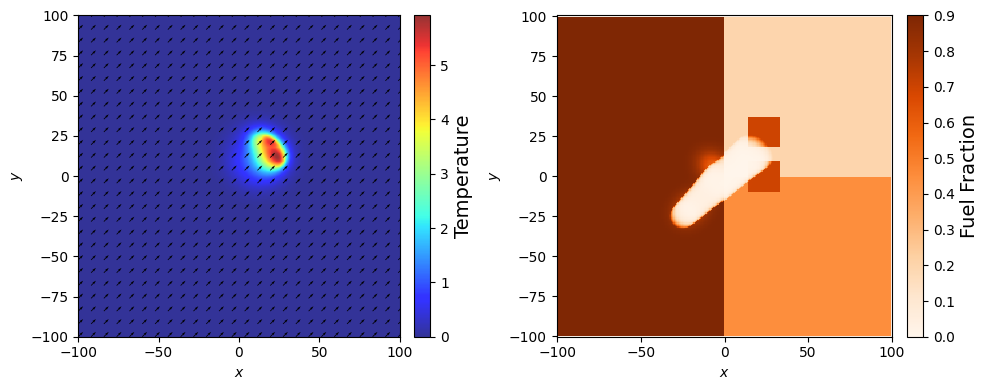

t:  10.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


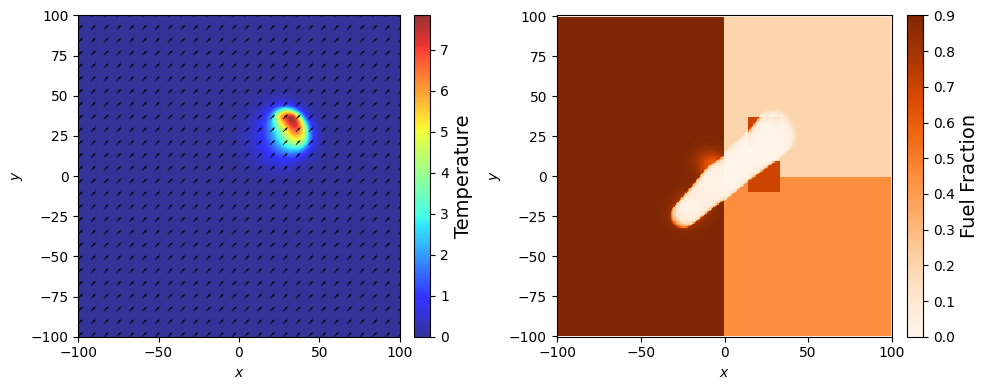

In [11]:
# Plotting with initial guess

real_x0 = np.asarray([-25, -25, (1/4)*np.pi, 0, 0, 0, (3/4)*np.pi, 3]) # initial guess
control_params['control_vars'] = real_x0 
opt_obj = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b0_test, V, weights, normalization_ranges)
t, X, Y, U, B = opt_obj.forward_eval(real_x0 , full_out=True)
# print(f"Objective function value is {opt_obj.objective_function(z0)}")
Ns = np.linspace(0, Nt, 5, dtype=int)
for n in Ns:
    plots.UBs(n, t, X, Y, U, B, V, control_params, forward=True)